# Introduction : Analyse du jeu de données MPG

Dans ce tutoriel, nous allons explorer en détail le jeu de données "mpg". Ce jeu de données, initialement publié par la bibliothèque StatLib de l'Université Carnegie Mellon et désormais disponible dans la bibliothèque Seaborn. L'objectif de ce tutoriel est d'explorer la relation entre la consommation de carburant (Miles Per Gallon, ou MPG) et diverses autres caractéristiques de ce jeu de données.

Le jeu de données "mpg" est particulièrement intéressant pour notre étude car il présente une combinaison de caractéristiques discrètes et continues. Il contient :

- 3 caractéristiques discrètes : Ces variables catégorielles nous permettront d'analyser des groupes ou des classifications au sein des données.
- 5 caractéristiques continues : Ces variables numériques nous permettront d'examiner des relations et des tendances quantitatives.

In [2]:
import seaborn as sns
# load a seaborn dataset
mpg_df = sns.load_dataset("mpg")
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Chargement du dataset MPG...
--- 5 premières lignes du dataset ---


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


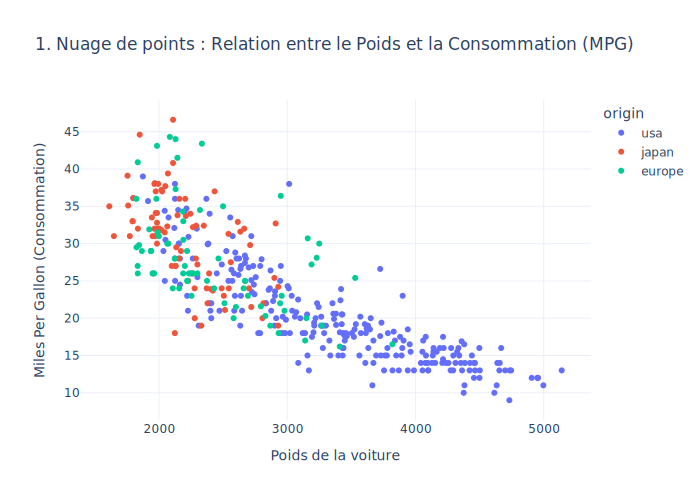

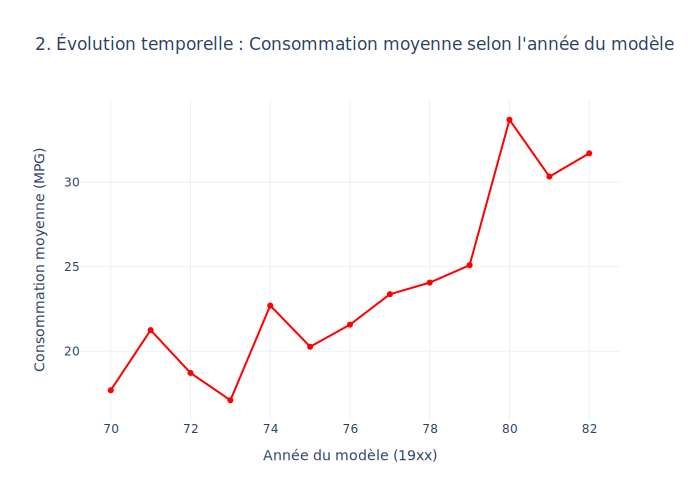

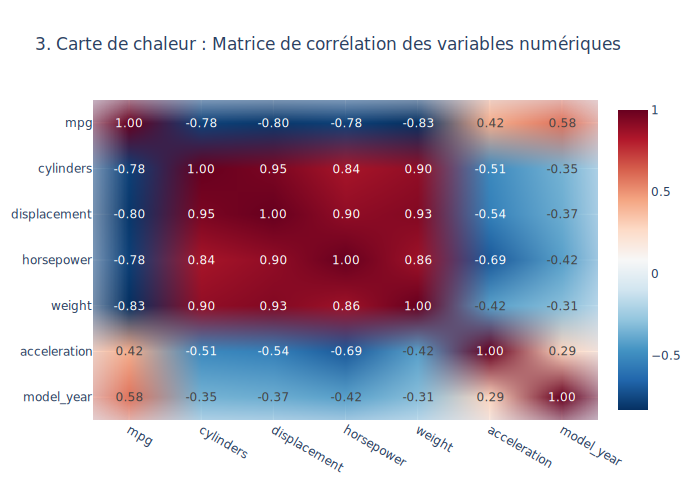

In [3]:
# --- ÉTAPE 1 : IMPORTATIONS ET CHARGEMENT ---
import seaborn as sns
import pandas as pd
import plotly.express as px
from IPython.display import display
import plotly.io as pio
pio.renderers.default = "svg"

print("Chargement du dataset MPG...")
mpg_df = sns.load_dataset("mpg")

print("--- 5 premières lignes du dataset ---")
display(mpg_df.head())


# --- ÉTAPE 2 : NUAGE DE POINTS (SCATTER PLOT) ---
# On compare le poids (weight) avec la consommation (mpg). 
# On colorie par continent d'origine (origin) et on affiche le nom de la voiture au survol.
fig_scatter = px.scatter(
    mpg_df, 
    x="weight", 
    y="mpg", 
    color="origin",
    hover_name="name",
    title="1. Nuage de points : Relation entre le Poids et la Consommation (MPG)",
    labels={"weight": "Poids de la voiture", "mpg": "Miles Per Gallon (Consommation)"},
    template="plotly_white"
)
fig_scatter.show()


# --- ÉTAPE 3 : GRAPHIQUE EN LIGNE (LINE PLOT) ---
# Pour faire une belle ligne, on va d'abord calculer la moyenne de MPG pour chaque année
avg_mpg_per_year = mpg_df.groupby('model_year')['mpg'].mean().reset_index()

fig_line = px.line(
    avg_mpg_per_year, 
    x="model_year", 
    y="mpg", 
    markers=True, # Ajoute des petits points sur la ligne
    title="2. Évolution temporelle : Consommation moyenne selon l'année du modèle",
    labels={"model_year": "Année du modèle (19xx)", "mpg": "Consommation moyenne (MPG)"},
    template="plotly_white"
)
fig_line.update_traces(line_color="red")
fig_line.show()


# --- ÉTAPE 4 : CARTE DE CHALEUR (HEATMAP) ---
# 1. On sélectionne uniquement les colonnes numériques (pour faire des calculs mathématiques)
numeric_df = mpg_df.select_dtypes(include=['number'])

# 2. On calcule la matrice de corrélation
corr_matrix = numeric_df.corr()

# 3. On génère la carte de chaleur avec Plotly
fig_heatmap = px.imshow(
    corr_matrix, 
    text_auto=".2f", # Affiche les chiffres avec 2 décimales dans les cases
    aspect="auto",
    color_continuous_scale="RdBu_r", # Rouge (corrélation négative) à Bleu (corrélation positive)
    title="3. Carte de chaleur : Matrice de corrélation des variables numériques"
)
fig_heatmap.show()